# Rethinking Chicago Crime Analysis

## Introduction

In this analysis, we will explore the crime data of Chicago to identify patterns and trends. We will use various data visualization techniques to gain insights into the types of crimes, their locations, and the times they occur.

## Data Collection

> Thanks to These projects:
> - https://www.kaggle.com/fahd09/eda-of-crime-in-chicago-2005-2016
> - 朱小波, 李昕, 叶信岳. 数据关联背景下芝加哥市一般盗窃案件的多维度分析[J]. 犯罪研究, 2018(4):10.

## Data Loading and Cleaning

Before we can analyze the data, we need to preprocess it. This includes handling missing values, converting data types, and creating new features if necessary.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gc

In [22]:
pd.set_option('display.max_columns', None)

In [23]:
Crime_2001_to_2004 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2001_to_2004.csv", on_bad_lines="warn", low_memory=False)
Crime_2005_to_2007 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2005_to_2007.csv", on_bad_lines="warn", low_memory=False)
Crime_2008_to_2011 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2008_to_2011.csv", on_bad_lines="warn", low_memory=False)
Crime_2012_to_2017 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2012_to_2017.csv", on_bad_lines="warn", low_memory=False)

C:\Users\hanpeng\AppData\Local\Temp\ipykernel_36964\1354416516.py:2: ParserWarning: Skipping line 533719: expected 23 fields, saw 24

  Crime_2005_to_2007 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2005_to_2007.csv", on_bad_lines="warn", low_memory=False)
C:\Users\hanpeng\AppData\Local\Temp\ipykernel_36964\1354416516.py:3: ParserWarning: Skipping line 1149094: expected 23 fields, saw 41

  Crime_2008_to_2011 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2008_to_2011.csv", on_bad_lines="warn", low_memory=False)


Verify all dataframes have the same columns

In [24]:
print(Crime_2001_to_2004.columns)
print(Crime_2005_to_2007.columns)
print(Crime_2008_to_2011.columns)
print(Crime_2012_to_2017.columns)

print("All dataframes have the same columns: ",
      set(Crime_2001_to_2004.columns) == set(Crime_2005_to_2007.columns) == set(Crime_2008_to_2011.columns) == set(Crime_2012_to_2017.columns))


Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location'],
      dtype='str')
Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location'],
      dtype='str')
Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location

Combine all dataframes into one for easier analysis

In [25]:
Crime_data = pd.concat([Crime_2001_to_2004, Crime_2005_to_2007, Crime_2008_to_2011, Crime_2012_to_2017], ignore_index=True)
del Crime_2001_to_2004
del Crime_2005_to_2007
del Crime_2008_to_2011
del Crime_2012_to_2017
gc.collect()
Crime_data.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,879,4786321,HM399414,01/01/2004 12:01:00 AM,082XX S COLES AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,424,4.0,7.0,46.0,06,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
1,2544,4676906,HM278933,03/01/2003 12:00:00 AM,004XX W 42ND PL,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,True,935,9.0,11.0,61.0,26,1173974.0,1876757.0,2003.0,04/15/2016 08:55:02 AM,41.817229156,-87.637328,"(41.817229156, -87.637328162)"
2,2919,4789749,HM402220,06/20/2004 11:00:00 AM,025XX N KIMBALL AVE,1752,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,False,1413,14.0,35.0,22.0,20,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
3,2927,4789765,HM402058,12/30/2004 08:00:00 PM,045XX W MONTANA ST,0840,THEFT,FINANCIAL ID THEFT: OVER $300,OTHER,False,False,2521,25.0,31.0,20.0,06,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
4,3302,4677901,HM275615,05/01/2003 01:00:00 AM,111XX S NORMAL AVE,0841,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,False,2233,22.0,34.0,49.0,06,1174948.0,1831051.0,2003.0,04/15/2016 08:55:02 AM,41.691784636,-87.635116,"(41.691784636, -87.635115968)"


Handle duplicate entries

In [26]:
print("Before handling duplicates: ", Crime_data.shape)
Crime_data.drop_duplicates(inplace=True)
print("After handling duplicates: ", Crime_data.shape)

Before handling duplicates:  (7941282, 23)
After handling duplicates:  (6170813, 23)


Convert 'Date' column to datetime format

In [27]:
Crime_data['Date'] = pd.to_datetime(Crime_data['Date'], format="%m/%d/%Y %I:%M:%S %p")

In [28]:
Crime_data.dtypes

Unnamed: 0                       int64
ID                               int64
Case Number                        str
Date                    datetime64[us]
Block                              str
IUCR                               str
Primary Type                       str
Description                        str
Location Description               str
Arrest                            bool
Domestic                          bool
Beat                             int64
District                       float64
Ward                           float64
Community Area                 float64
FBI Code                           str
X Coordinate                   float64
Y Coordinate                    object
Year                           float64
Updated On                         str
Latitude                        object
Longitude                      float64
Location                           str
dtype: object

### Are IDs unique?

In [29]:
# Count cases with the same id and their counts
id_counts = Crime_data['ID'].value_counts()
duplicate_ids = id_counts[id_counts > 1]
print(f"Number of duplicate IDs: {len(duplicate_ids)}")
print(duplicate_ids.head())

Number of duplicate IDs: 1
ID
1423259    2
Name: count, dtype: int64


In [30]:
# Display these duplicate IDs and their corresponding rows, sorted by ID
duplicate_rows = Crime_data[Crime_data['ID'].isin(duplicate_ids.index)].sort_values(by='ID')
duplicate_rows
# duplicate_rows.iloc[90:96]

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
89258,3629582,1423259,G139165,2001-03-10 23:30:00,035XX S FEDERAL ST,1340,CRIMINAL DAMAGE,TO STATE SUP PROP,CHA PARKING LOT/GROUNDS,True,False,211,2.0,NaN,NaN,14,1176246.0,1881591.0,2001.000000,08/17/2015 03:03:40 PM,41.830443262,-87.628849,"(41.830443262, -87.628848503)"
1602847,3629582,1423259,G139165,2001-03-10 23:30:00,035XX S FEDERAL ST,1340,CRIMINAL DAMAGE,TO STATE SUP PROP,CHA PARKING LOT/GROUNDS,True,False,211,2.0,NaN,NaN,14,1176246.0,18 08:55:02 AM,41.789832,-87.672973835,"(41.789832136, -87.672973835)",NaN,NaN


So we remove 1602847 because it looks wrong and is duplicated in the dataset. We will check for other potential misaligned rows later.

In [31]:
# remove the duplicated row with index 1602847 because it looks wrong and is duplicated in the dataset
Crime_data.drop(index=1602847, inplace=True)

### Data Quality Assessment

Check for missing values and wrong data types, and row misalignment

In [32]:
# Data quality assessment: missing values, wrong data types, and possible row misalignment

print(f"Rows: {len(Crime_data):,} | Columns: {Crime_data.shape[1]}")

# 1) Missing values
missing_summary = (
    Crime_data.isna().sum()
    .rename("missing_count")
    .to_frame()
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(Crime_data) * 100).round(3)
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)

print("\nColumns with missing values:")
print(missing_summary)

# 2) Wrong data types / malformed values
numeric_cols = [
    "Unnamed: 0", "ID", "Beat", "District", "Ward", "Community Area",
    "X Coordinate", "Y Coordinate", "Year", "Latitude", "Longitude"
]

type_issues = {}
for col in numeric_cols:
    if col in Crime_data.columns:
        bad_mask = Crime_data[col].notna() & pd.to_numeric(Crime_data[col], errors="coerce").isna()
        bad_count = int(bad_mask.sum())
        if bad_count > 0:
            type_issues[col] = bad_count

# Date column validation
date_bad = Crime_data["Date"].isna().sum() if "Date" in Crime_data.columns else None

# Updated On validation (string datetime in source data)
updated_on_bad = None
if "Updated On" in Crime_data.columns:
    updated_on_parsed = pd.to_datetime(Crime_data["Updated On"], errors="coerce")
    updated_on_bad = int(Crime_data["Updated On"].notna().sum() - updated_on_parsed.notna().sum())

print("\nPotential type issues (non-null values that fail expected parsing):")
print(type_issues if type_issues else "None found")

print(f"\nUnparseable Date values: {date_bad:,}" if date_bad is not None else "\nDate column not found")
print(f"Unparseable Updated On values: {updated_on_bad:,}" if updated_on_bad is not None else "Updated On column not found")

# 3) Row misalignment checks (heuristics)
year_num = pd.to_numeric(Crime_data["Year"], errors="coerce")
lat_num = pd.to_numeric(Crime_data["Latitude"], errors="coerce")
lon_num = pd.to_numeric(Crime_data["Longitude"], errors="coerce")
ycoord_str = Crime_data["Y Coordinate"].astype(str)

reason_parts = pd.Series([""] * len(Crime_data), index=Crime_data.index)

missing_id_mask = Crime_data["ID"].isna()
bad_year_mask = year_num.notna() & ~year_num.between(2001, 2017)
bad_lat_mask = lat_num.notna() & ~lat_num.between(30, 50)
bad_lon_mask = lon_num.notna() & ~lon_num.between(-125, -65)
bad_ycoord_mask = ycoord_str.str.contains("AM|PM|:", na=False)

reason_parts[missing_id_mask] += "missing ID; "
reason_parts[bad_year_mask] += f"year out of range ({year_num[bad_year_mask].unique().tolist()}); "
reason_parts[bad_lat_mask] += "latitude out of Chicago range; "
reason_parts[bad_lon_mask] += "longitude out of Chicago range; "
reason_parts[bad_ycoord_mask] += "time-like string in Y Coordinate; "

misaligned_mask = missing_id_mask | bad_year_mask | bad_lat_mask | bad_lon_mask | bad_ycoord_mask

misaligned_rows = Crime_data[misaligned_mask].copy()
misaligned_rows["suspicious_reason"] = reason_parts[misaligned_mask].str.rstrip("; ")

print(f"\nPotentially misaligned/suspicious rows: {len(misaligned_rows):,}")

if len(misaligned_rows) > 0:
    # display_cols = [
    #     "ID", "Case Number", "Date", "Block", "Y Coordinate", "Year",
    #     "Updated On", "Latitude", "Longitude", "Location"
    # ]
    # display(misaligned_rows[display_cols].head(10))
    display(misaligned_rows.head(4))

Rows: 6,170,812 | Columns: 23

Columns with missing values:
                      missing_count  missing_pct
Community Area               616041        9.983
Ward                         614864        9.964
Longitude                     84223        1.365
Latitude                      84223        1.365
X Coordinate                  84223        1.365
Y Coordinate                  84223        1.365
Location                      84223        1.365
Location Description           1968        0.032
District                         49        0.001
Case Number                       4        0.000


C:\Users\hanpeng\AppData\Local\Temp\ipykernel_36964\12132927.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  updated_on_parsed = pd.to_datetime(Crime_data["Updated On"], errors="coerce")



Potential type issues (non-null values that fail expected parsing):
None found

Unparseable Date values: 0
Unparseable Updated On values: 0

Potentially misaligned/suspicious rows: 0


## Exploratory Data Analysis

### Types of Crimes

In [33]:
unique_crimes = Crime_data['Primary Type'].unique().tolist()
print(f"Total unique crime types: {len(unique_crimes)}")
print(unique_crimes)

Total unique crime types: 35
['THEFT', 'OTHER OFFENSE', 'OFFENSE INVOLVING CHILDREN', 'CRIM SEXUAL ASSAULT', 'MOTOR VEHICLE THEFT', 'SEX OFFENSE', 'DECEPTIVE PRACTICE', 'BATTERY', 'BURGLARY', 'WEAPONS VIOLATION', 'PUBLIC PEACE VIOLATION', 'NARCOTICS', 'GAMBLING', 'PROSTITUTION', 'LIQUOR LAW VIOLATION', 'INTERFERENCE WITH PUBLIC OFFICER', 'CRIMINAL DAMAGE', 'ASSAULT', 'STALKING', 'ARSON', 'CRIMINAL TRESPASS', 'HOMICIDE', 'ROBBERY', 'OBSCENITY', 'KIDNAPPING', 'INTIMIDATION', 'RITUALISM', 'DOMESTIC VIOLENCE', 'OTHER NARCOTIC VIOLATION', 'PUBLIC INDECENCY', 'NON-CRIMINAL', 'HUMAN TRAFFICKING', 'CONCEALED CARRY LICENSE VIOLATION', 'NON - CRIMINAL', 'NON-CRIMINAL (SUBJECT SPECIFIED)']


Primary Type
THEFT                                1284608
BATTERY                              1125725
CRIMINAL DAMAGE                       710082
NARCOTICS                             674556
OTHER OFFENSE                         381714
ASSAULT                               376888
BURGLARY                              361624
MOTOR VEHICLE THEFT                   291030
ROBBERY                               233527
DECEPTIVE PRACTICE                    223245
CRIMINAL TRESPASS                     178002
PROSTITUTION                           65533
WEAPONS VIOLATION                      60640
PUBLIC PEACE VIOLATION                 44732
OFFENSE INVOLVING CHILDREN             40233
CRIM SEXUAL ASSAULT                    23607
SEX OFFENSE                            22631
GAMBLING                               13884
LIQUOR LAW VIOLATION                   13422
INTERFERENCE WITH PUBLIC OFFICER       12869
ARSON                                  10279
HOMICIDE                                82

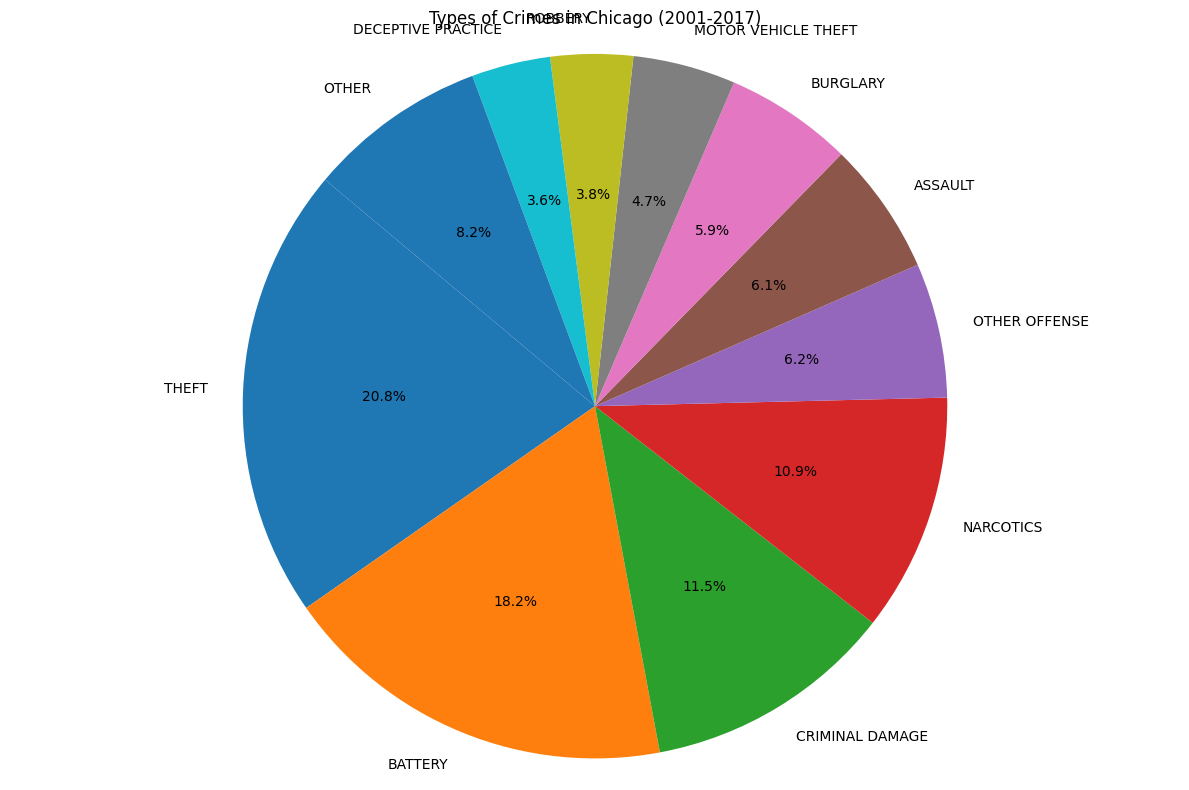

In [34]:
crime_counts = Crime_data['Primary Type'].value_counts()
print(crime_counts)

top_crimes = crime_counts.head(10)
other_count = crime_counts.iloc[10:].sum()
plot_data = pd.concat([top_crimes, pd.Series({'OTHER': other_count})])

plt.figure(figsize=(12, 8))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=140)
plt.title('Types of Crimes in Chicago (2001-2017)')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Non-geographic Missing values?

In [35]:
# Check missing values across all columns
missing_counts = Crime_data.isna().sum().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": (missing_counts / len(Crime_data) * 100).round(2)
})

# Show only columns with missing values
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
print("Columns with missing values:\n")
print(missing_summary)

# Test whether missing data is only in geographic fields
geo_cols = {"X Coordinate", "Y Coordinate", "Latitude", "Longitude", "Location"}
non_geo_missing = [col for col in missing_summary.index if col not in geo_cols]

if not non_geo_missing:
    print("\nYes — missing values are only in geographic information columns.")
else:
    print("\nNo — there are missing values in non-geographic columns too:")
    print(non_geo_missing)

Columns with missing values:

                      missing_count  missing_pct
Community Area               616041         9.98
Ward                         614864         9.96
X Coordinate                  84223         1.36
Location                      84223         1.36
Y Coordinate                  84223         1.36
Longitude                     84223         1.36
Latitude                      84223         1.36
Location Description           1968         0.03
District                         49         0.00
Case Number                       4         0.00

No — there are missing values in non-geographic columns too:
['Community Area', 'Ward', 'Location Description', 'District', 'Case Number']


What are the case numbers that are missing?

In [36]:
missing_case_rows = Crime_data[Crime_data["Case Number"].isna()]

print(f"Number of missing case numbers: {len(missing_case_rows)}")
# missing_case_rows[["ID", "Date", "Block", "Primary Type", "Case Number"]]
missing_case_rows

Number of missing case numbers: 4


,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
4425181,1503746,7014449,NaN,2009-07-10 11:00:00,082XX S HARPER AVE,0560,ASSAULT,SIMPLE,STREET,False,False,411,4.0,8.0,45.0,08A,1187910.0,1850555.0,2009.0,02/04/2016 06:33:39 AM,41.745008,-87.587042,"(41.74500765, -87.587041972)"
4447882,1526447,7049552,NaN,2009-07-30 03:00:00,058XX N PAULINA ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2012,20.0,40.0,77.0,14,1164170.0,1938694.0,2009.0,02/04/2016 06:33:39 AM,41.987401,-87.671539,"(41.987401038, -87.671539153)"
4809787,1888354,7610078,NaN,2010-07-16 14:56:00,005XX W VAN BUREN ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,111,1.0,2.0,28.0,08B,1172646.0,1898435.0,2010.0,02/04/2016 06:33:39 AM,41.876745,-87.641559,"(41.876744768, -87.641559043)"
7759089,5192747,8475075,NaN,2012-02-08 22:00:00,032XX N KILDARE AVE,0620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,1731,17.0,31.0,16.0,05,NaN,NaN,2012.0,05/04/2016 03:48:23 PM,NaN,NaN,NaN


In [37]:
# Find cases with id appeeared in missing case rows in the dataset
missing_case_ids = missing_case_rows["ID"].dropna().unique()
print(f"Unique IDs in missing case rows: {len(missing_case_ids)}")

Crime_data[Crime_data["ID"].isin(missing_case_ids)]

Unique IDs in missing case rows: 4


,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
4425181,1503746,7014449,NaN,2009-07-10 11:00:00,082XX S HARPER AVE,0560,ASSAULT,SIMPLE,STREET,False,False,411,4.0,8.0,45.0,08A,1187910.0,1850555.0,2009.0,02/04/2016 06:33:39 AM,41.745008,-87.587042,"(41.74500765, -87.587041972)"
4447882,1526447,7049552,NaN,2009-07-30 03:00:00,058XX N PAULINA ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2012,20.0,40.0,77.0,14,1164170.0,1938694.0,2009.0,02/04/2016 06:33:39 AM,41.987401,-87.671539,"(41.987401038, -87.671539153)"
4809787,1888354,7610078,NaN,2010-07-16 14:56:00,005XX W VAN BUREN ST,0460,BATTERY,SIMPLE,SIDEWALK,True,False,111,1.0,2.0,28.0,08B,1172646.0,1898435.0,2010.0,02/04/2016 06:33:39 AM,41.876745,-87.641559,"(41.876744768, -87.641559043)"
7759089,5192747,8475075,NaN,2012-02-08 22:00:00,032XX N KILDARE AVE,0620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,1731,17.0,31.0,16.0,05,NaN,NaN,2012.0,05/04/2016 03:48:23 PM,NaN,NaN,NaN


So cases numbers are missing in the dataset, but we can still analyze the data based on other features.

### Missing Value percentage for each type of crime

In [38]:
# Calculate missing percentage by crime type for each column
missing_by_crime_type = {}

for crime_type in Crime_data["Primary Type"].unique():
    crime_data = Crime_data[Crime_data["Primary Type"] == crime_type]
    missing_counts = crime_data.isna().sum()
    missing_pct = (missing_counts / len(crime_data) * 100).round(2)
    missing_by_crime_type[crime_type] = missing_pct

# Create a DataFrame with crime types as rows and columns as columns
missing_pct_by_crime_type = pd.DataFrame(missing_by_crime_type).T

# Display only columns that have missing values in at least one crime type
cols_with_missing = missing_pct_by_crime_type.columns[missing_pct_by_crime_type.sum(axis=0) > 0]
missing_pct_by_crime_type_filtered = missing_pct_by_crime_type[cols_with_missing]

# Sort by the first column with missing values
print(f"Missing value percentage by crime type ({len(Crime_data['Primary Type'].unique())} crime types):\n")
if len(cols_with_missing) > 0:
    print(missing_pct_by_crime_type_filtered.sort_values(cols_with_missing[0], ascending=False))
else:
    print("No missing values found")

Missing value percentage by crime type (35 crime types):

                                   Location Description  District    Ward  \
DECEPTIVE PRACTICE                                 0.55      0.00    8.00   
THEFT                                              0.06      0.00    9.56   
OTHER OFFENSE                                      0.00      0.00   10.37   
OFFENSE INVOLVING CHILDREN                         0.00      0.00    6.39   
CRIM SEXUAL ASSAULT                                0.00      0.00    8.82   
MOTOR VEHICLE THEFT                                0.00      0.00   11.29   
SEX OFFENSE                                        0.00      0.01   11.33   
BATTERY                                            0.00      0.00   10.51   
BURGLARY                                           0.00      0.00    8.99   
WEAPONS VIOLATION                                  0.00      0.00    9.19   
PUBLIC PEACE VIOLATION                             0.00      0.00    7.64   
NARCOTICS         

In [39]:
missing_pct_by_crime_type_filtered

,Location Description,District,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Location
THEFT,0.06,0.00,9.56,9.58,1.53,1.53,1.53,1.53,1.53
OTHER OFFENSE,0.00,0.00,10.37,10.39,1.28,1.28,1.28,1.28,1.28
OFFENSE INVOLVING CHILDREN,0.00,0.00,6.39,6.40,5.51,5.51,5.51,5.51,5.51
CRIM SEXUAL ASSAULT,0.00,0.00,8.82,8.85,5.91,5.91,5.91,5.91,5.91
MOTOR VEHICLE THEFT,0.00,0.00,11.29,11.30,1.45,1.45,1.45,1.45,1.45
SEX OFFENSE,0.00,0.01,11.33,11.35,5.01,5.01,5.01,5.01,5.01
DECEPTIVE PRACTICE,0.55,0.00,8.00,8.02,4.81,4.81,4.81,4.81,4.81
BATTERY,0.00,0.00,10.51,10.53,0.90,0.90,0.90,0.90,0.90
BURGLARY,0.00,0.00,8.99,9.01,0.85,0.85,0.85,0.85,0.85
WEAPONS VIOLATION,0.00,0.00,9.19,9.21,1.03,1.03,1.03,1.03,1.03


### Keeping only thefts for further analysis

As we planned, we will focus on thefts for our analysis. We will filter the dataset to include only rows where the 'Primary Type' is 'THEFT'.

In [40]:
Theft_data = Crime_data[Crime_data["Primary Type"] == "THEFT"].copy()
print(f"Theft data shape: {Theft_data.shape}")
del Crime_data
gc.collect()

Theft data shape: (1284608, 23)


3616